<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/Opt_cap_extended_model_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimized Capacity Extended Model — Colab Version

원본 `Opt_cap_extended_model(2).py`를 Google Colab에서 단독 실행할 수 있도록 정리한 노트북입니다. 전기 급전 한계, ASE 잡음, Kerr 비선형 잡음, 코어 간 누화 및 FIFO 손실을 고려하여 span length별 최적 전송 용량을 계산합니다.

## 사용 방법

1. 아래 셀을 위에서부터 순서대로 실행합니다.
2. **입력 파라미터** 셀의 값을 실제 시스템 조건으로 바꿉니다.
3. 실제 EDFA 전기-광 변환효율 맵이 있으면 예제 `eta` 배열을 교체합니다.

이 노트북은 원본에서 외부 파일로 불러오던 `SNR_GD`, `dB2Lin`, `Lin2dB` 등을 내부에 포함합니다. 따라서 별도의 `.py` 파일 업로드가 필요 없습니다. 원본의 고정 인덱스 `1000`은 실제 배열 길이를 사용하도록 바꾸었고, 반환되는 `eta_m`은 각 span에서 실제로 선택된 최적 launch power의 효율입니다.

주요 단위: `L_span`, `Ltot` [km], `NF` [dB], `V_PFE` [V], `R` [Ω/km], `gamma` [1/(W·km)], `gamma_XT` [1/km, linear], `alpha` [dB/km], `D` [s/(km·nm)], `Rs`, `delta_f`, `B` [Hz], `Ps` [W], `lamb` [nm].

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def dB2Lin(value_dB):
    return 10.0 ** (np.asarray(value_dB) / 10.0)

def dBm2Lin(value_dBm):
    return 1e-3 * 10.0 ** (np.asarray(value_dBm) / 10.0)

def Lin2dB(value_linear):
    with np.errstate(divide='ignore', invalid='ignore'):
        return 10.0 * np.log10(np.asarray(value_linear))

def Lin2dBm(value_W):
    with np.errstate(divide='ignore', invalid='ignore'):
        return 10.0 * np.log10(np.asarray(value_W) / 1e-3)

def find_nearest(array, value):
    array = np.asarray(array)
    idx = np.abs(array - value).argmin()
    return idx, array[idx]

In [2]:
def SNR_GD(Ps, lamb, alpha, NF, N, gamma, Ltot, B, D, Rs,
           gamma_XT, l_FIFO, delta_f):
    """Generalized Droop model SNR (linear scale).

    Ps is total WDM launch power in watts. gamma_XT is a linear
    crosstalk coefficient in 1/km; set it to 0 to disable XT.
    """
    Ps = np.asarray(Ps, dtype=float)
    if np.any(Ps <= 0):
        raise ValueError('Ps must contain positive power values in watts.')
    if N < 1 or alpha <= 0 or B <= 0 or delta_f <= 0 or Rs <= 0:
        raise ValueError('N, alpha, B, delta_f, and Rs must be positive.')

    h = 6.62607015e-34       # J·s
    c = 2.99792458e17        # nm/s
    f = c / lamb             # Hz
    N_ch = B / delta_f
    P_ch = Ps / N_ch
    alpha_lin = alpha / 4.343
    NF_lin = 10.0 ** (NF / 10.0)

    beta_2 = -D * lamb**2 / (2.0 * np.pi * c)  # s²/km
    alpha_span = alpha * Ltot / N + 2.0 * l_FIFO
    G_lin = 10.0 ** (alpha_span / 10.0)
    P_ASE = h * f * NF_lin * Rs * (G_lin - 1.0)
    chi_a = (1.0 + P_ASE / P_ch) ** (-1.0)

    L_eff = (1.0 - np.exp(-alpha_lin * Ltot / N)) / alpha_lin
    L_effa = 1.0 / alpha_lin
    asinh_arg = (
        np.pi**2 / 2.0 * np.abs(beta_2) * L_effa * Rs**2
        * N_ch ** (2.0 * Rs / delta_f)
    )
    alpha_NLI = (
        8.0 / 27.0 * gamma**2 * L_eff**2 * np.arcsinh(asinh_arg)
        / (np.pi * np.abs(beta_2) * L_effa * Rs**2)
    )
    SNR_1R_NLI = 1.0 / (alpha_NLI * P_ch**2)

    if gamma_XT == 0:
        SNR_1R = SNR_1R_NLI
    else:
        SNR_1R_XT = 1.0 / (gamma_XT * Ltot / N)
        SNR_1R = 1.0 / (1.0 / SNR_1R_NLI + 1.0 / SNR_1R_XT)

    chi_r = (1.0 + 1.0 / SNR_1R) ** (-1.0)
    return 1.0 / ((chi_a**(-1.0) * chi_r**(-1.0))**N - 1.0)

In [3]:
def optimized_capacity_extended(
    L_span, Ltot, NF, V_PFE, R, eta, epsilon, M, gamma, gamma_XT,
    alpha, l_FIFO, D, Rs, delta_f, Ps, lamb, B, L_span_min
):
    """Optimize capacity under electrical-power and propagation limits.

    Returns
    -------
    eta_m : ndarray
        E/O efficiency at the selected optimum power for each span length.
    L_spanmax : float
        Span length [km] at the selected maximum capacity.
    C_max : float
        Maximum aggregate capacity [bit/s].
    SNR_max : float
        Maximum SNR at L_spanmax [linear].
    max_SNR_linear : ndarray
        Optimized SNR curve for every span length [linear].
    max_power : ndarray
        Selected total WDM launch power for every span length [W].
    """
    L_span = np.asarray(L_span, dtype=float)
    Ps = np.asarray(Ps, dtype=float)
    eta = np.asarray(eta, dtype=float)
    if L_span.ndim != 1 or Ps.ndim != 1:
        raise ValueError('L_span and Ps must be one-dimensional arrays.')
    if eta.shape[0] < len(L_span) + 1 or eta.shape[1] < len(Ps) + 1:
        raise ValueError('eta must have shape at least (len(L_span)+1, len(Ps)+1).')

    N = np.floor(Ltot / L_span).astype(int)
    if np.any(N < 1):
        raise ValueError('Every L_span must be less than or equal to Ltot.')

    N_ch = B / delta_f
    eta_eo = eta[1:len(L_span)+1, 1:len(Ps)+1]
    max_SNR_dB = np.full(len(L_span), np.nan)
    max_power = np.full(len(L_span), np.nan)
    eta_m = np.full(len(L_span), np.nan)
    M_amp = 2 * M

    for i in range(len(L_span)):
        P_elecmax = V_PFE**2 * (1.0 - epsilon) * eta_eo[i, :] / (4.0 * R * Ltot)
        P_maxchannel = P_elecmax / (N[i] * M_amp)
        feasible_idx = np.flatnonzero(Ps < P_maxchannel)

        if feasible_idx.size == 0:
            continue

        # The source model assumes the feasible power region is contiguous.
        stop = feasible_idx[-1] + 1
        candidate_power = Ps[:stop]
        candidate_snr = SNR_GD(
            candidate_power, lamb, alpha, NF, N[i], gamma, Ltot, B, D, Rs,
            gamma_XT, l_FIFO, delta_f
        )
        best = int(np.nanargmax(candidate_snr))
        max_SNR_dB[i] = Lin2dB(candidate_snr[best])
        max_power[i] = candidate_power[best]
        eta_m[i] = eta_eo[i, best]

    max_SNR_linear = dB2Lin(max_SNR_dB)
    C = M * N_ch * Rs * np.log2(1.0 + max_SNR_linear)
    if np.all(np.isnan(C)):
        raise ValueError('No feasible launch power was found for any span length.')

    selected = int(np.nanargmax(C))
    if L_span[selected] < L_span_min:
        candidates = np.flatnonzero(L_span >= L_span_min)
        if candidates.size == 0:
            raise ValueError('L_span_min is greater than every value in L_span.')
        selected = int(candidates[0])

    return (
        eta_m, L_span[selected], C[selected], max_SNR_linear[selected],
        max_SNR_linear, max_power
    )

## 입력 파라미터 예제

아래 값은 **실행 확인용 예시**입니다. 특히 `eta`는 실제 EDFA 데이터가 아니라 span gain과 출력 파워에 따른 가상 효율 맵입니다. 실제 분석 시 제조사 데이터 또는 측정 데이터로 교체하십시오.

In [4]:
# Span and cable conditions
L_span = np.linspace(40.0, 120.0, 81)  # km
Ltot = 6000.0                           # km
NF = 5.0                                # dB
V_PFE = 12_000.0                        # V
R = 1.0                                 # ohm/km
epsilon = 0.10                          # fractional circuit loss
M = 8                                   # number of fiber pairs

# Optical-fiber and WDM conditions
gamma = 1.2                             # 1/(W·km)
gamma_XT = 0.0                          # 1/km (linear); 0 disables XT
alpha = 0.16                            # dB/km
l_FIFO = 0.5                            # dB per FIFO
D = 17e-12                              # s/(km·nm) = 17 ps/(km·nm)
Rs = 32e9                               # baud
delta_f = 50e9                          # Hz
Ps = np.logspace(-3, 0, 1000)           # total WDM launch power [W]
lamb = 1550.0                           # nm
B = 4.0e12                              # Hz
L_span_min = 50.0                       # km

# Illustrative E/O efficiency map. Replace this block with measured eta data.
gain_dB = alpha * L_span[:, None] + 2.0 * l_FIFO
power_dBm = Lin2dBm(Ps)[None, :]
eta_eo_example = np.clip(
    0.040 + 0.015 * np.exp(-((power_dBm - 20.0) / 8.0)**2)
    - 0.00005 * (gain_dB - 15.0)**2,
    0.015, 0.060
)
eta = np.empty((len(L_span) + 1, len(Ps) + 1))
eta[0, 0] = np.nan
eta[0, 1:] = Ps
eta[1:, 0] = L_span
eta[1:, 1:] = eta_eo_example

print(f'eta shape: {eta.shape}, channels: {B/delta_f:.0f}')

eta shape: (82, 1001), channels: 80


In [5]:
eta_m, L_spanmax, C_max, SNR_max, SNR_curve, max_power = optimized_capacity_extended(
    L_span, Ltot, NF, V_PFE, R, eta, epsilon, M, gamma, gamma_XT,
    alpha, l_FIFO, D, Rs, delta_f, Ps, lamb, B, L_span_min
)

N_ch = B / delta_f
capacity_curve = M * N_ch * Rs * np.log2(1.0 + SNR_curve)
selected_idx = find_nearest(L_span, L_spanmax)[0]

print(f'Selected span length : {L_spanmax:.1f} km')
print(f'Repeaters (floor)     : {int(np.floor(Ltot/L_spanmax))}')
print(f'Maximum capacity      : {C_max/1e12:.3f} Tb/s')
print(f'SNR at selected span  : {Lin2dB(SNR_max):.3f} dB')
print(f'Total launch power    : {Lin2dBm(max_power[selected_idx]):.3f} dBm')
print(f'E/O efficiency        : {100*eta_m[selected_idx]:.3f} %')

Selected span length : 50.0 km
Repeaters (floor)     : 120
Maximum capacity      : 93.285 Tb/s
SNR at selected span  : 13.523 dB
Total launch power    : 14.745 dBm
E/O efficiency        : 4.794 %


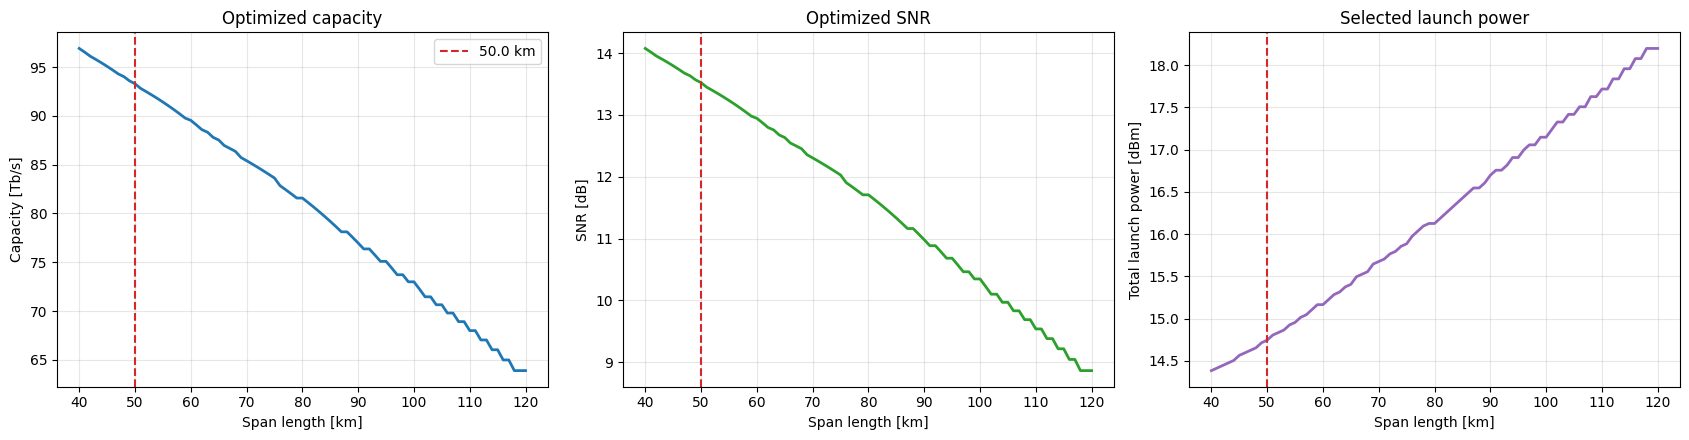

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(L_span, capacity_curve / 1e12, lw=2)
axes[0].axvline(L_spanmax, color='tab:red', ls='--', label=f'{L_spanmax:.1f} km')
axes[0].set(xlabel='Span length [km]', ylabel='Capacity [Tb/s]', title='Optimized capacity')
axes[0].legend()

axes[1].plot(L_span, Lin2dB(SNR_curve), lw=2, color='tab:green')
axes[1].axvline(L_spanmax, color='tab:red', ls='--')
axes[1].set(xlabel='Span length [km]', ylabel='SNR [dB]', title='Optimized SNR')

axes[2].plot(L_span, Lin2dBm(max_power), lw=2, color='tab:purple')
axes[2].axvline(L_spanmax, color='tab:red', ls='--')
axes[2].set(xlabel='Span length [km]', ylabel='Total launch power [dBm]', title='Selected launch power')

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()